In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
from google.colab import drive
drive.mount('/content/drive')

ruta = "/content/drive/MyDrive/Ciencia de datos/Datos TPI 2026/"

data_clientes = pd.read_excel(ruta + "dataset_K_Means.xlsx")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_1253/3831923998.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(title='Cluster', bbox_to_anchor=(1.05, 1))


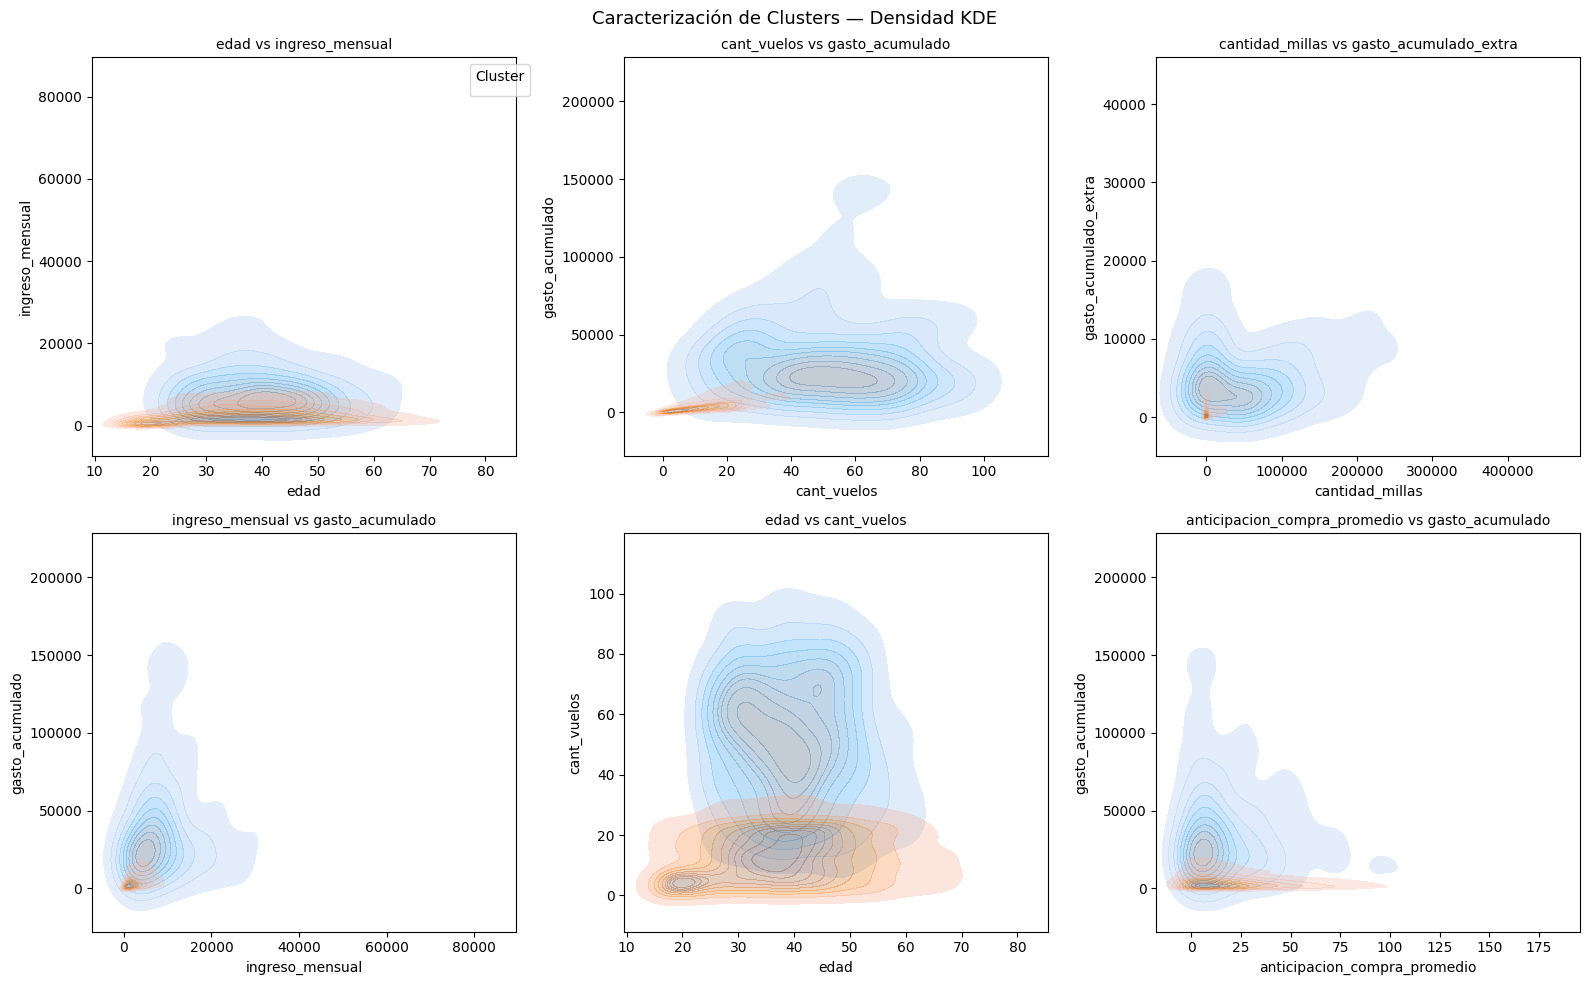

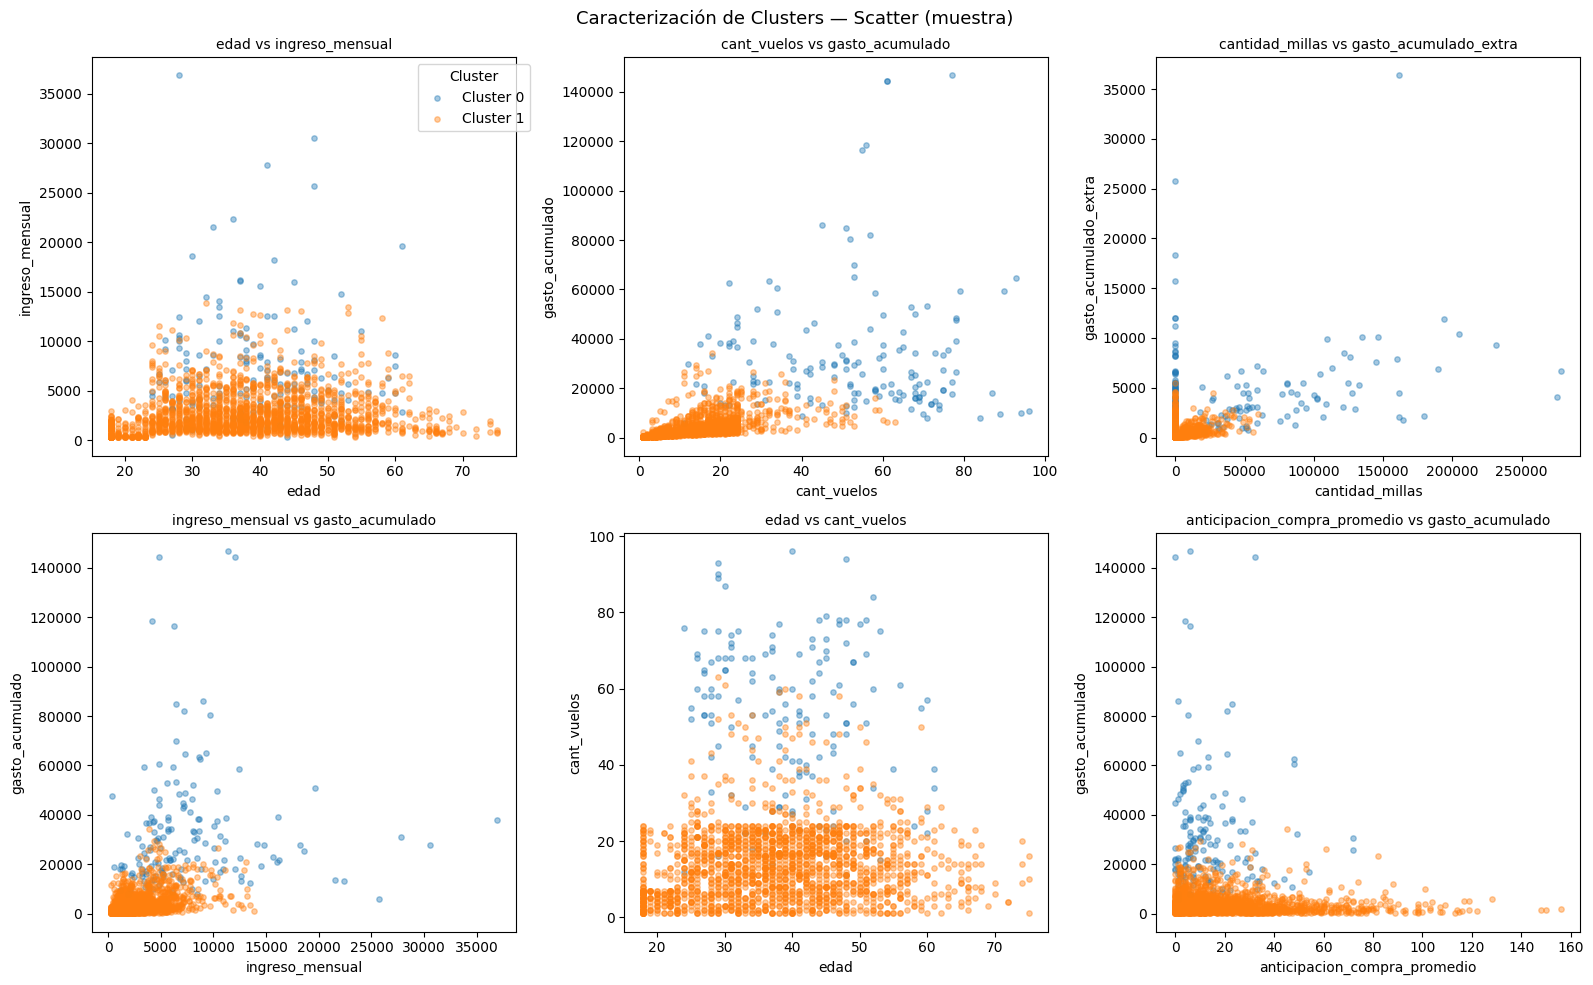

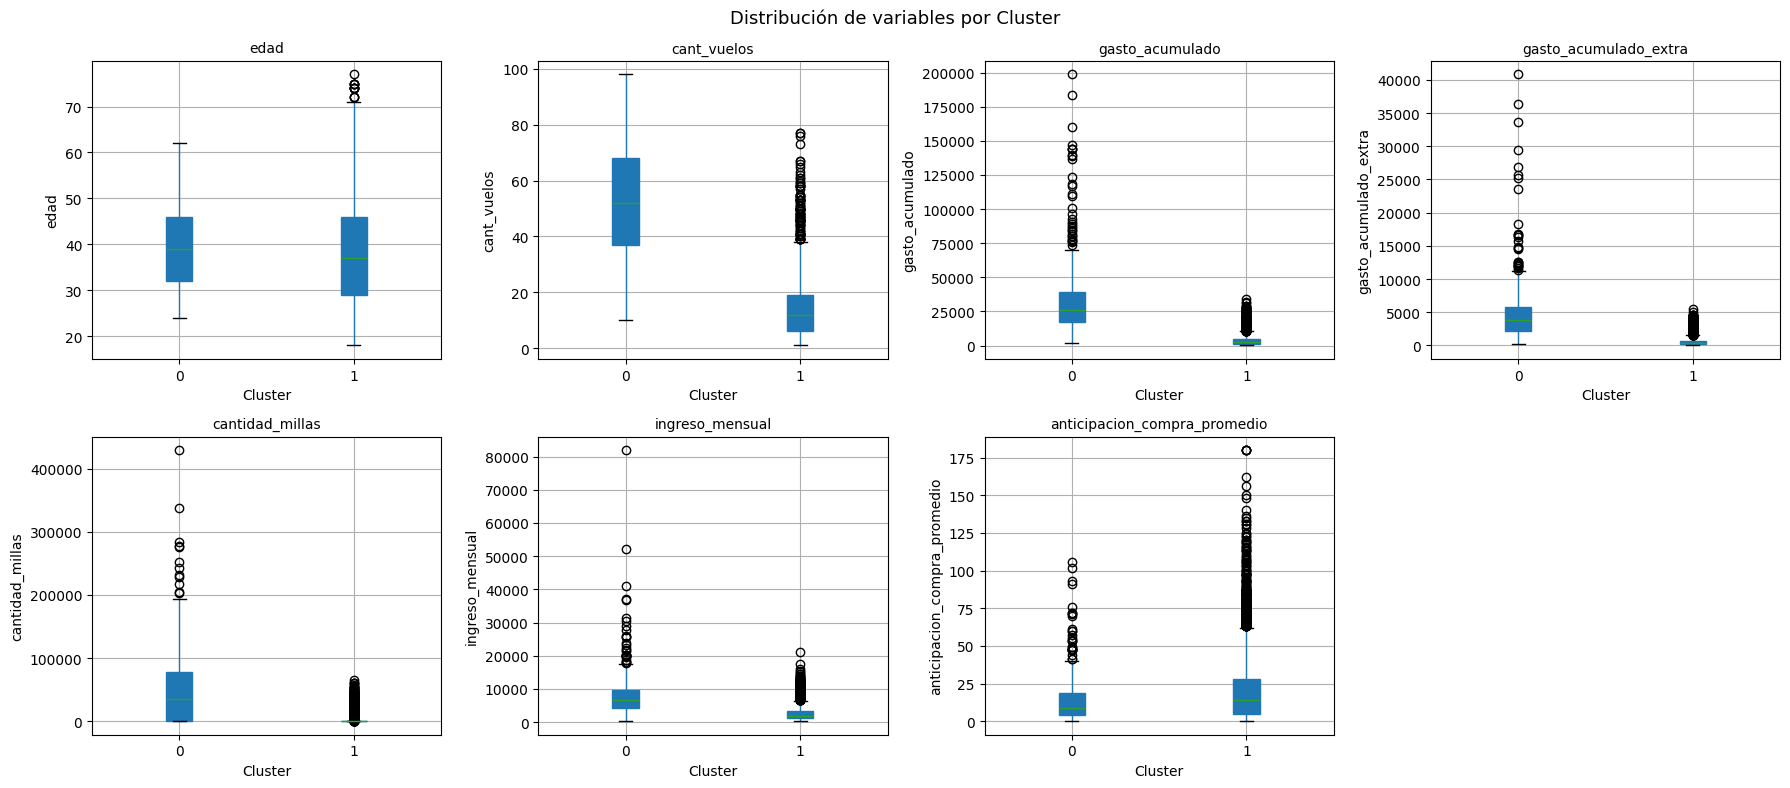

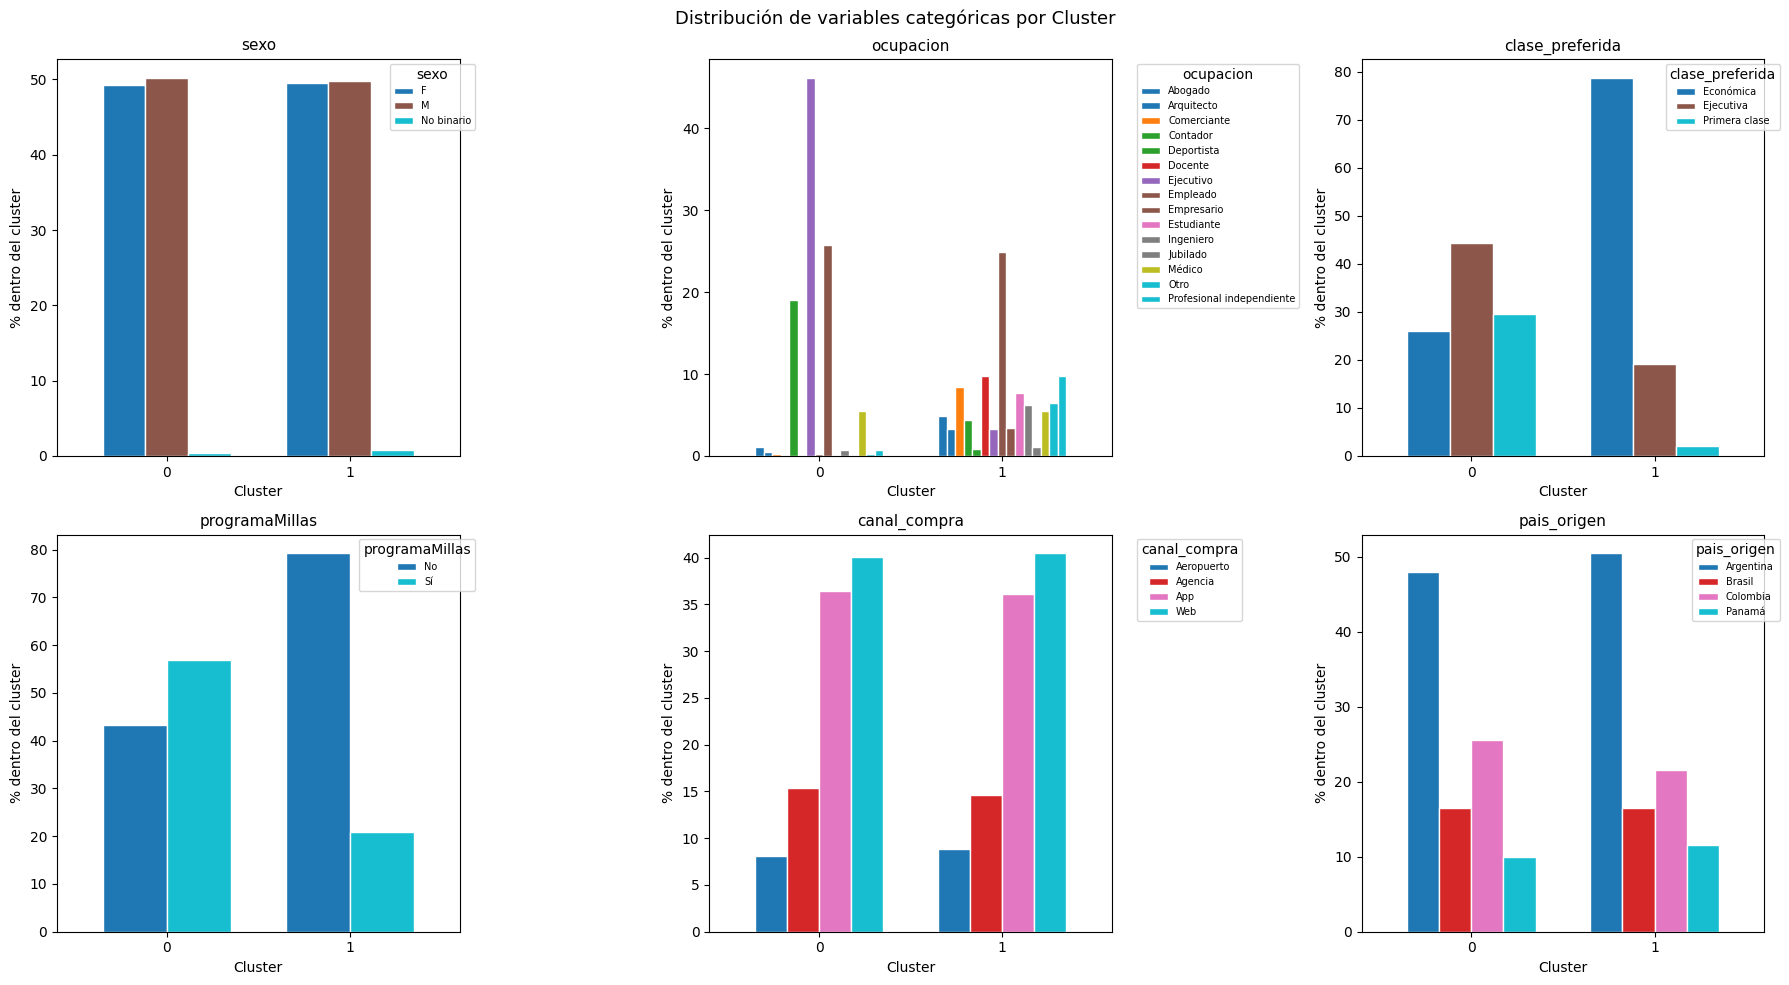

In [20]:

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Variables numéricas a cruzar
vars_num = ['edad', 'cant_vuelos', 'gasto_acumulado',
            'gasto_acumulado_extra', 'cantidad_millas',
            'ingreso_mensual', 'anticipacion_compra_promedio']

col_cluster = 'cluster_kmeans'

# Paleta de colores por cluster
palette = sns.color_palette("tab10", n_colors=data_clientes[col_cluster].nunique())

# ── OPCIÓN 1: KDE plots (mejor para muchos datos) ──────────────
pares = [
    ('edad', 'ingreso_mensual'),
    ('cant_vuelos', 'gasto_acumulado'),
    ('cantidad_millas', 'gasto_acumulado_extra'),
    ('ingreso_mensual', 'gasto_acumulado'),
    ('edad', 'cant_vuelos'),
    ('anticipacion_compra_promedio', 'gasto_acumulado'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (x, y) in enumerate(pares):
    ax = axes[idx]
    for cluster_id, color in zip(sorted(data_clientes[col_cluster].unique()), palette):
        subset = data_clientes[data_clientes[col_cluster] == cluster_id]
        sns.kdeplot(data=subset, x=x, y=y, ax=ax,
                    color=color, fill=True, alpha=0.3,
                    label=f'Cluster {cluster_id}', warn_singular=False)
    ax.set_title(f'{x} vs {y}', fontsize=10)
    ax.set_xlabel(x)
    ax.set_ylabel(y)

axes[0].legend(title='Cluster', bbox_to_anchor=(1.05, 1))
plt.suptitle('Caracterización de Clusters — Densidad KDE', fontsize=13)
plt.tight_layout()
plt.savefig('clusters_kde.png', dpi=150, bbox_inches='tight')
plt.show()


# ── OPCIÓN 2: Scatter con muestra (más visual) ─────────────────
muestra = data_clientes.sample(n=min(2000, len(data_clientes)), random_state=42)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (x, y) in enumerate(pares):
    ax = axes[idx]
    for cluster_id, color in zip(sorted(muestra[col_cluster].unique()), palette):
        subset = muestra[muestra[col_cluster] == cluster_id]
        ax.scatter(subset[x], subset[y], c=[color], alpha=0.4,
                   s=15, label=f'Cluster {cluster_id}')
    ax.set_title(f'{x} vs {y}', fontsize=10)
    ax.set_xlabel(x)
    ax.set_ylabel(y)

axes[0].legend(title='Cluster', bbox_to_anchor=(1.05, 1))
plt.suptitle('Caracterización de Clusters — Scatter (muestra)', fontsize=13)
plt.tight_layout()
plt.savefig('clusters_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


# ── OPCIÓN 3: Boxplots por cluster (muy claro para el informe) ─
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for idx, var in enumerate(vars_num):
    ax = axes[idx]
    data_clientes.boxplot(column=var, by=col_cluster, ax=ax,
                patch_artist=True)
    ax.set_title(var, fontsize=10)
    ax.set_xlabel('Cluster')
    ax.set_ylabel(var)

axes[-1].set_visible(False)
plt.suptitle('Distribución de variables por Cluster', fontsize=13)
plt.tight_layout()
plt.savefig('clusters_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()


# ── OPCIÓN 4 (BONUS): Categóricas por cluster ──────────────────
vars_cat = ['sexo', 'ocupacion', 'clase_preferida', 'programaMillas',
            'canal_compra', 'pais_origen']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, var in enumerate(vars_cat):
    ax = axes[idx]
    tabla = data_clientes.groupby([col_cluster, var]).size().unstack(fill_value=0)
    tabla_pct = tabla.div(tabla.sum(axis=1), axis=0) * 100
    tabla_pct.plot(kind='bar', ax=ax, colormap='tab10',
                   edgecolor='white', width=0.7)
    ax.set_title(var, fontsize=11)
    ax.set_xlabel('Cluster')
    ax.set_ylabel('% dentro del cluster')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(title=var, bbox_to_anchor=(1.05, 1), fontsize=7)

plt.suptitle('Distribución de variables categóricas por Cluster', fontsize=13)
plt.tight_layout()
plt.savefig('clusters_categoricas.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:


ruta = "/content/drive/MyDrive/Ciencia de datos/Datos TPI 2026/"

data_vuelos_nuevos = pd.read_excel(ruta+"dataset_con_clusters.xlsx")

vuelos_demorados = data_vuelos_nuevos[data_vuelos_nuevos["demora"]==1]

ids_demorados = vuelos_demorados["id_vuelo"].tolist()

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Ciencia de datos/Datos TPI 2026/casosNuevos.xlsx'

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ruta = "/content/drive/MyDrive/Ciencia de datos/Datos TPI 2026/"

clientes = pd.read_excel(ruta+"dataset_K_Means.xlsx")


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Ciencia de datos/Datos TPI 2026/dataset_K_Means.xlsx'

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ruta = "/content/drive/MyDrive/Ciencia de datos/Datos TPI 2026/"

clientes = pd.read_excel(ruta + "dataset_con_clusters.xlsx")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Ciencia de datos/Datos TPI 2026/dataset_con_clusters.xlsx'

In [ ]:
data_vuelos_clientes = pd.read_excel(ruta+"casosNuevos.xlsx",sheet_name="VuelosNuevos_Clientes")

data_vuelos_clientes = data_vuelos_clientes[data_vuelos_clientes["id_vuelo"].isin(ids_demorados)]
id_clientes_demorados = data_vuelos_clientes["id_cliente"].drop_duplicates().tolist()

In [ ]:
len(id_clientes_demorados)

48913

In [ ]:
path = "/content/drive/MyDrive/Ciencia de datos/Datos TPI 2026/"

from google.colab import drive
drive.mount('/content/drive')

dfC = pd.read_excel(path + "dataset_transformado.xlsx")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
dfC.describe()

,id_cliente,edad,cant_vuelos,gasto_acumulado,gasto_acumulado_extra,cantidad_millas,ingreso_mensual,anticipacion_compra_promedio
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000
mean,25000.500000,37.827400,17.071860,6587.557023,953.732059,6759.361980,3062.882160,19.91066
std,14433.901067,11.479385,15.750424,12439.879256,1987.615263,23529.642402,3780.380841,21.40158
min,1.000000,18.000000,1.000000,71.250000,3.210000,0.000000,300.000000,0.00000
25%,12500.750000,29.000000,6.000000,1404.575000,167.480000,0.000000,1250.000000,5.00000
50%,25000.500000,38.000000,14.000000,3099.895000,403.255000,0.000000,2100.000000,13.00000
75%,37500.250000,46.000000,21.000000,6317.357500,912.547500,0.000000,3823.000000,27.00000
max,50000.000000,80.000000,99.000000,253140.320000,47394.970000,541589.000000,350075.000000,180.00000


In [ ]:
Numericas = ['edad', 'cant_vuelos', 'gasto_acumulado', 'gasto_acumulado_extra', 'cantidad_millas', 'ingreso_mensual', 'anticipacion_compra_promedio']

list_x = Numericas

scaler = StandardScaler()
df_Z = scaler.fit_transform(dfC[list_x])

df_Z = pd.DataFrame(df_Z, columns=list_x)
df_Z.head()

,edad,cant_vuelos,gasto_acumulado,gasto_acumulado_extra,cantidad_millas,ingreso_mensual,anticipacion_compra_promedio
0,-1.204554,0.249401,-0.068807,0.135283,0.525030,-0.448605,-0.790167
1,0.973285,-0.068053,-0.321080,-0.222899,-0.287273,0.843605,0.471434
2,0.276376,-0.448999,-0.300403,-0.164381,-0.287273,-0.388822,-0.182729
3,-1.640122,-0.512490,-0.308539,-0.208046,-0.287273,-0.582191,1.265776
4,-0.594759,-0.068053,-0.067245,-0.068516,-0.287273,-0.035944,0.284530


In [ ]:
df_muestra = df_Z.sample(n=500, random_state=42)

Z = linkage(df_muestra, 'ward')

In [ ]:
Z

array([[2.84000000e+02, 3.06000000e+02, 5.38250656e-02, 2.00000000e+00],
       [3.98000000e+02, 4.31000000e+02, 5.99922433e-02, 2.00000000e+00],
       [3.36000000e+02, 3.39000000e+02, 9.07639035e-02, 2.00000000e+00],
       ...,
       [9.91000000e+02, 9.95000000e+02, 2.48146479e+01, 4.44000000e+02],
       [9.90000000e+02, 9.93000000e+02, 3.22146790e+01, 5.60000000e+01],
       [9.96000000e+02, 9.97000000e+02, 4.38150714e+01, 5.00000000e+02]])

In [ ]:
from scipy.cluster.hierarchy import fcluster

# Recalculás con ward si no lo hiciste
Z = linkage(df_Z, 'ward')

# Asignás 2 clusters a cada registro
labels = fcluster(Z, t=2, criterion='maxclust')

# Lo agregás al dataframe original
dfC['cluster'] = labels

dfC['cluster'].value_counts()

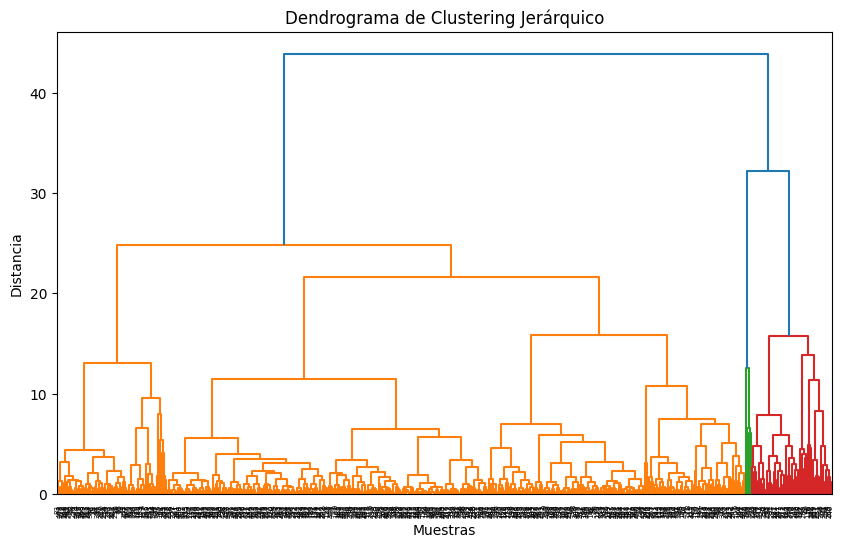

In [ ]:
# Crear un dendrograma
plt.figure(figsize=(10, 6))
dendrogram(Z)
plt.title('Dendrograma de Clustering Jerárquico')
plt.xlabel('Muestras')
plt.ylabel('Distancia')
plt.show()